<a href="https://colab.research.google.com/github/venezianof/booksum/blob/main/gpt_ossmio030626pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Agente di Ricerca Medica: Terapie e Immagini
Questo modulo configura un agente capace di interrogare database medici (come PubMed/Medline via API) per trovare terapie innovative basate su imaging, fornendo abstract e link diretti.

In [5]:
import requests
import xml.etree.ElementTree as ET
from typing import List, Dict

def search_medline(query: str, max_results: int = 5) -> List[Dict]:
    """
    Interroga l'API Entrez di NCBI per trovare articoli e abstract reali su Medline.
    """
    base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"

    # 1. Ricerca degli ID
    search_params = {'db': 'pubmed', 'term': query, 'retmode': 'json', 'retmax': max_results}
    id_list = requests.get(base_url + "esearch.fcgi", params=search_params).json().get('esearchresult', {}).get('idlist', [])

    if not id_list:
        return []

    # 2. Recupero Abstract e Dettagli via EFetch (XML)
    fetch_params = {'db': 'pubmed', 'id': ','.join(id_list), 'retmode': 'xml'}
    r_fetch = requests.get(base_url + "efetch.fcgi", params=fetch_params)
    root = ET.fromstring(r_fetch.content)

    results = []
    for article in root.findall('.//PubmedArticle'):
        pmid = article.find('.//PMID').text
        title = article.find('.//ArticleTitle').text

        # Estrazione Abstract
        abstract_text = "Abstract non disponibile."
        abstract_element = article.find('.//AbstractText')
        if abstract_element is not None:
            abstract_text = "".join(abstract_element.itertext())
            if len(abstract_text) > 300: abstract_text = abstract_text[:297] + "..."

        results.append({
            'title': title,
            'link': f"https://pubmed.ncbi.nlm.nih.gov/{pmid}/",
            'abstract': abstract_text
        })
    return results

In [10]:
# Esecuzione con numero di risultati aumentato (max_results = 10)
query_medica = "immunotherapy lung cancer"
ricerche = search_medline(query_medica, max_results=10)

print(f"--- Risultati Medici (Top 10) per: {query_medica} ---\n")
for i, res in enumerate(ricerche, 1):
    print(f"{i}. {res['title']}")
    print(f"   Link: {res['link']}")
    print(f"   Abstract: {res['abstract']}\n")

--- Risultati Medici (Top 10) per: immunotherapy lung cancer ---

1. Plain language summary: comparing ivonescimab plus chemotherapy with tislelizumab plus chemotherapy in people with advanced squamous non-small cell lung cancer in the HARMONi-6 study.
   Link: https://pubmed.ncbi.nlm.nih.gov/42233228/
   Abstract: What is this summary about?HARMONi-6 is a study that looked at a new treatment for people with advanced squamous non-small cell lung cancer in China. People participating in the study received first-line treatment (meaning they had not taken any medicine for their cancer before the study). Ivones...

2. Tumor immune microenvironment in non-small cell lung cancer progression.
   Link: https://pubmed.ncbi.nlm.nih.gov/42233035/
   Abstract: Non-small cell lung cancer (NSCLC), the most prevalent form of lung malignancy, remains a leading cause of cancer-related mortality despite advances in surgery, targeted therapy, and immunotherapy. A growing body of evidence implicates the t

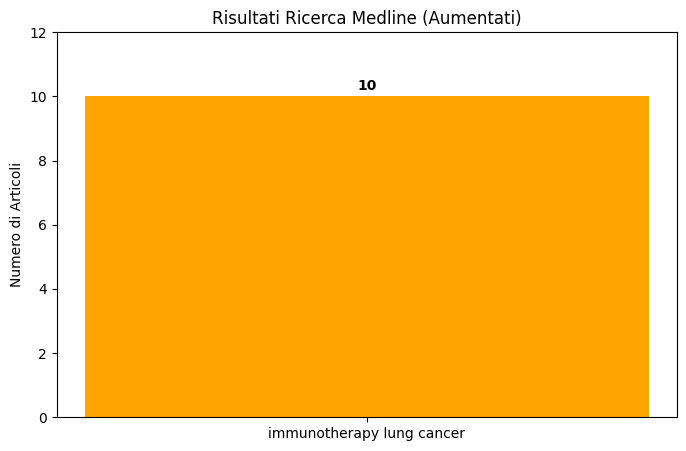

In [11]:
import matplotlib.pyplot as plt

# Aggiornamento del grafico con il nuovo conteggio
labels = [query_medica]
counts = [len(ricerche)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, counts, color='orange')

ax.set_ylabel('Numero di Articoli')
ax.set_title('Risultati Ricerca Medline (Aumentati)')
ax.set_ylim(0, max(counts) + 2)

for i, v in enumerate(counts):
    ax.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.show()

In [12]:
import collections
import re

# Combine all abstracts into one string
all_text = " ".join([res['abstract'].lower() for res in ricerche])

# Remove punctuation and split into words
words = re.findall(r'\w+', all_text)

# Filter out common stop words
stop_words = {'the', 'and', 'in', 'of', 'to', 'a', 'with', 'is', 'for', 'on', 'this', 'was', 'as', 'at', 'that', 'by', 'an', 'study', 'are', 'from', 'but', 'also'}
filtered_words = [w for w in words if w not in stop_words and len(w) > 3]

# Count frequencies
word_counts = collections.Counter(filtered_words).most_common(15)

# Display the top keywords
print("Parole chiave più frequenti negli abstract:")
for word, count in word_counts:
    print(f"{word}: {count}")

Parole chiave più frequenti negli abstract:
cancer: 16
lung: 12
small: 7
cell: 7
treatment: 5
remains: 5
advanced: 4
nsclc: 4
mortality: 4
immunotherapy: 4
tumor: 4
their: 3
leading: 3
cause: 3
related: 3


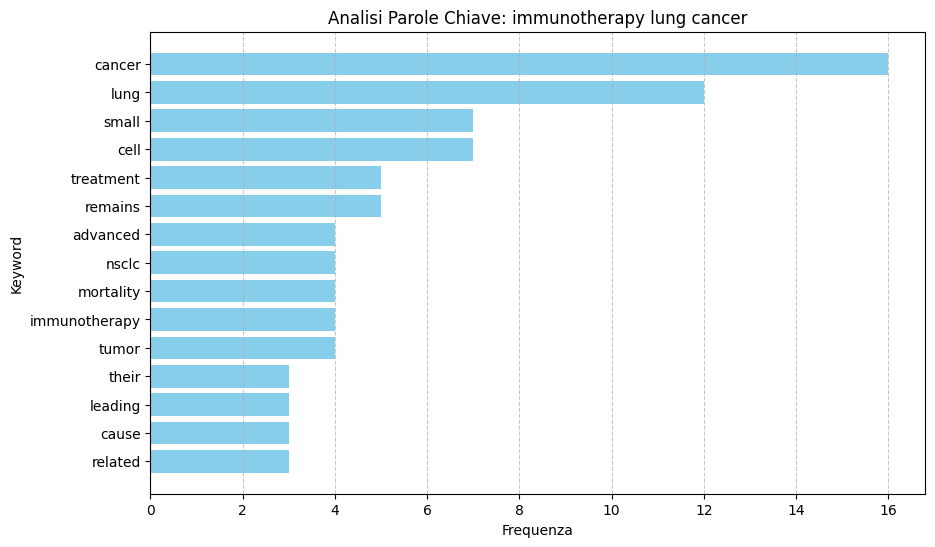

In [13]:
import matplotlib.pyplot as plt

if word_counts:
    keywords, counts = zip(*word_counts)

    plt.figure(figsize=(10, 6))
    plt.barh(keywords, counts, color='skyblue')
    plt.gca().invert_yaxis()  # Put the most frequent at the top
    plt.title(f'Analisi Parole Chiave: {query_medica}')
    plt.xlabel('Frequenza')
    plt.ylabel('Keyword')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Nessun dato sufficiente per generare il grafico.")

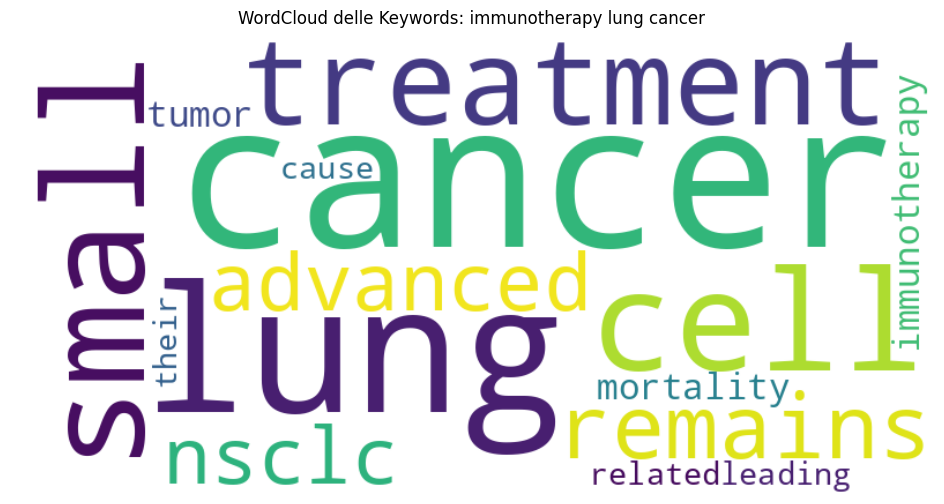

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Creazione del dizionario delle frequenze dalle analisi precedenti
if 'word_counts' in globals():
    dizionario_frequenze = dict(word_counts)

    # Generazione del WordCloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate_from_frequencies(dizionario_frequenze)

    # Visualizzazione
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud delle Keywords: {query_medica}')
    plt.show()
else:
    print("Eseguire prima la cella di analisi delle parole chiave.")

### 1. Installation & Environment Setup
We begin by installing the Unsloth library and its dependencies, which allow for memory-efficient training of large models on consumer GPUs like the Tesla T4.

In [ ]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-prttkhvi/unsloth_4e14c134f42149049c7477e88b5adda0
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-prttkhvi/unsloth_4e14c134f42149049c7477e88b5adda0
  Resolved https://github.com/unslothai/unsloth.git to commit b0572bd233efc120d50a940f13af89eb879d0dd0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.4/924.4 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 9.7 MB/s eta 0:00:00


### 2. Model Configuration
We load the GPT-OSS 20B model in 4-bit quantization to fit within the T4's 16GB VRAM and apply LoRA adapters.

In [ ]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/gpt-oss-20b",
    max_seq_length = max_seq_length,
    load_in_4bit = load_in_4bit,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 128,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 32,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)

NotImplementedError: Unsloth cannot find any torch accelerator? You need a GPU.

In [ ]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048
load_in_4bit = True

# Load the model and tokenizer
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/gpt-oss-20b",
    max_seq_length = max_seq_length,
    load_in_4bit = load_in_4bit,
)

# Add LoRA adapters
model = FastLanguageModel.get_peft_model(
    model,
    r = 128,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 32,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
)
print("Model successfully loaded on GPU!")

NotImplementedError: Unsloth cannot find any torch accelerator? You need a GPU.

### 3. Reward Functions
We define the logic to evaluate the model's output. This includes checking for syntax, ensuring no external libraries like NumPy are imported (anti-cheating), and measuring execution speed relative to a baseline.

In [ ]:
import ast
import time
import numpy as np

def correctness_reward(prompts, completions, **kwargs):
    rewards = []
    for completion in completions:
        try:
            # Basic validation of syntax and logic
            exec_globals = {}
            exec(completion, exec_globals)
            if 'matmul' in exec_globals:
                rewards.append(1.0)
            else:
                rewards.append(0.0)
        except Exception:
            rewards.append(0.0)
    return rewards

def anti_cheating_reward(prompts, completions, **kwargs):
    rewards = []
    for completion in completions:
        # AST check to prevent numpy or torch imports
        tree = ast.parse(completion)
        cheating = False
        for node in ast.walk(tree):
            if isinstance(node, ast.Import) or isinstance(node, ast.ImportFrom):
                cheating = True
        rewards.append(0.0 if cheating else 1.0)
    return rewards